# 2.3 特征工程：量化交易的“炼金术”


> **这一节讲什么？**
> 
> 从 OHLCV 原始数据到能喂给机器学习模型的特征矩阵，这一节是关键的"炼金术"。核心原则：用收益率而非价格（平稳性），用滚动标准化而非全局缩放（防止未来泄露）。

## 学习目标
- 从 OHLCV 原始数据构建有价值的预测特征
- **严谨性：掌握平稳性检验（ADF Test）处理非平稳价格序列**
- **防御性：理解滚动标准化（Rolling Scaling）防止未来泄露**
- 构建滞后特征与未来标签，避免 Look-ahead Bias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# 下载数据
raw = yf.download('AAPL', start='2022-01-01', end='2024-01-01', progress=False)
df = pd.DataFrame({
    'Open': raw['Open'].squeeze(),
    'High': raw['High'].squeeze(),
    'Low': raw['Low'].squeeze(),
    'Close': raw['Close'].squeeze(),
    'Volume': raw['Volume'].squeeze(),
})
# .squeeze()的作用，会让数据变成这样：date日期消失了（变成了默认的整数索引 0,1,2...），为了给机器学习喂代码，需要去掉非字符类型数据
#     Open   High    Low  Close    Volume
# 0  248.0  249.5  247.0  248.5  10000000
# 1  247.5  248.0  246.5  247.8   9500000
# Series (一维，只有1列)：squeeze()的结果就是series
# Date
# 2022-12-16    248.0
# 2022-12-17    247.5
# Name: Open, dtype: float64
print(f'原始数据内容后20行和前20行：\n{df.tail(20)}\n{df.tail(20)}')
print(f'\n原始数据准备就绪: {df.shape}')

原始数据内容后20行和前20行：
                  Open        High         Low       Close     Volume
Date                                                                 
2023-12-01  188.199700  189.415928  187.112005  189.099518   45704800
2023-12-04  187.853585  187.922809  185.351904  187.309738   43389500
2023-12-05  188.081049  192.224139  188.051371  191.255112   66628400
2023-12-06  192.273599  192.580127  189.959794  190.167450   41089700
2023-12-07  191.462745  192.817406  191.423184  192.095581   47477700
2023-12-08  192.026392  193.796366  191.502325  193.519501   53406400
2023-12-11  190.948568  191.324319  189.277481  191.017776   60943700
2023-12-12  190.918909  192.540553  189.574131  192.530670   52696900
2023-12-13  192.906406  195.783839  192.669102  195.744293   70404200
2023-12-14  195.803635  197.385718  193.964453  195.892624   66831600
2023-12-15  195.319097  196.179355  194.795030  195.358658  128538400
2023-12-18  193.895238  194.429202  192.214268  193.697479   55751900
202

In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 为什么“价格”不能直接做特征？ (平稳性原则)

> **QuantEcon 核心观点**：
> 大多数量化模型要求输入数据是**平稳的 (Stationary)**。平稳意味着数据的均值和方差不会随着时间发生巨大漂移。
> 
> **价格是不平稳的**（今天 100 元，明年可能 200 元），直接用价格训练模型会导致“伪回归”。我们需要使用**收益率**或**价格差分**。

In [4]:
# ADF 检验：判别数据是否平稳 (p-value < 0.05 则平稳)
def check_stationarity(series, name):
    result = adfuller(series.dropna()) # Augmented Dickey-Fuller 检验，统计学上用来判断序列是否平稳的“考官”。
    # series.dropna()：先把序列中的空值（NaN）扔掉，否则 adfuller 会报错。
    print(f"{name} ADF p-value: {result[1]:.5f} {'(平稳 ✅)' if result[1] < 0.05 else '(不平稳 ❌)'}")

check_stationarity(df['Close'], "收盘价")
check_stationarity(df['Close'].pct_change(), "日收益率")

print("结论：在特征工程中，请尽量使用收益率或振幅，而不是原始价格。")

收盘价 ADF p-value: 0.52739 (不平稳 ❌)
日收益率 ADF p-value: 0.00000 (平稳 ✅)
结论：在特征工程中，请尽量使用收益率或振幅，而不是原始价格。


## 2. 构造基础特征矩阵

In [6]:
# 收益率特征
df['ret_1d'] = df['Close'].pct_change() #日收益率
df['ret_5d'] = df['Close'].pct_change(5) #5日收益率

# 波动与动量
df['vol_20d'] = df['ret_1d'].rolling(20).std()
# -- 过去20天的历史波动率：用日收益率序列，创建一个20天的“滑动窗口”，计算窗口内收益率的标准差
# -- 标准差越小 → 股价越平稳 → 波动率越低
# -- 数值越大，说明股价波动越剧烈，是风险度量的重要指标
df['ma_ratio'] = df['Close'] / df['Close'].rolling(20).mean() - 1
# -- 计算价格相对20日滚动移动平均（MA20)的偏离度：
# 均值回归策略：
# ma_ratio 过大（如 > 5%）→ 价格可能过高，准备卖出
# ma_ratio 过小（如 < -5%）→ 价格可能过低，准备买入
# 趋势强度判断：
# 持续正值 → 上升趋势
# 持续负值 → 下降趋势


# 价格形态特征
df['upper_shadow'] = (df['High'] - np.maximum(df['Close'], df['Open'])) / df['Close']
df['lower_shadow'] = (np.minimum(df['Close'], df['Open']) - df['Low']) / df['Close']
# -- 这两行代码是在计算K线（蜡烛图）的上影线和下影线相对于收盘价的长度比例。这是量化分析中常见的一种技术特征工程，用于**捕捉日内多空博弈的信息**。
# -- 上影线长度 ÷ 收盘价，表示上影线相对于价格水平的比例。
# -- 下影线长度 ÷ 收盘价，表示下影线相对于价格水平的比例。
# -- upper_shadow = (最高价 - 实体顶部) / 收盘价 → 上方抛压强度
# -- lower_shadow = (实体底部 - 最低价) / 收盘价 → 下方支撑强度
print(f'特征构建的内容后20行：\n{df.tail(20)}')
print("特征构建完成")

特征构建的内容后20行：
                  Open        High         Low       Close     Volume  \
Date                                                                    
2023-12-01  188.199700  189.415928  187.112005  189.099518   45704800   
2023-12-04  187.853585  187.922809  185.351904  187.309738   43389500   
2023-12-05  188.081049  192.224139  188.051371  191.255112   66628400   
2023-12-06  192.273599  192.580127  189.959794  190.167450   41089700   
2023-12-07  191.462745  192.817406  191.423184  192.095581   47477700   
2023-12-08  192.026392  193.796366  191.502325  193.519501   53406400   
2023-12-11  190.948568  191.324319  189.277481  191.017776   60943700   
2023-12-12  190.918909  192.540553  189.574131  192.530670   52696900   
2023-12-13  192.906406  195.783839  192.669102  195.744293   70404200   
2023-12-14  195.803635  197.385718  193.964453  195.892624   66831600   
2023-12-15  195.319097  196.179355  194.795030  195.358658  128538400   
2023-12-18  193.895238  194.429202  19

## 3. 防御性特征工程：滚动标准化

### 陷阱：全局标准化
很多教程教你用 `StandardScaler().fit(X)` 处理整个数据集。这会产生 **Look-ahead Bias**：在计算第 100 天的特征时，你实际上参考了第 500 天的数据（因为模型计算了全局均值）。

### 对策：滚动标准化 (Rolling Scaling)
只使用**过去 N 天**的数据来计算当天的均值和标准差进行缩放。

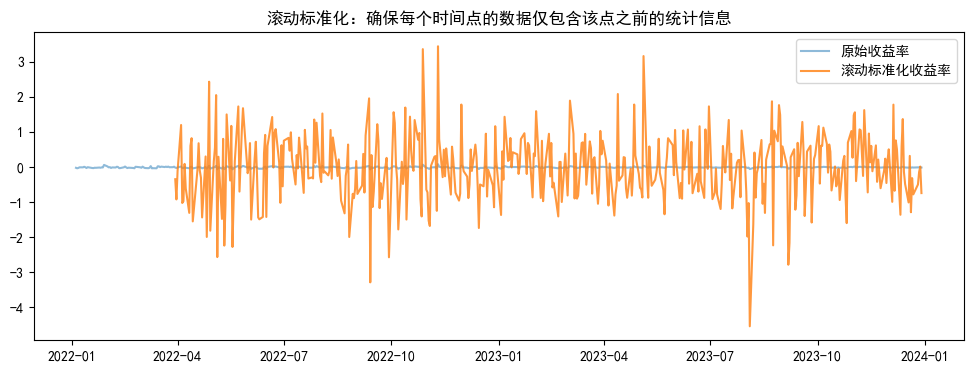

In [7]:
def rolling_scale(series, window=60):#滚动窗口大小，默认60期
    mean = series.rolling(window).mean()#60期内的移动平均值
    std = series.rolling(window).std()#60期的标准差
    return (series - mean) / std #这是Z-Score标准化公式的滚动版本
    # 滚动Z-Score标准化 —— 将当前值转换为"偏离过去N期平均值多少个标准差"
    # > 0	当前值高于近期平均水平
    # ≈ 0	当前值接近近期平均水平
    # < 0	当前值低于近期平均水平
    # > +2	显著偏高（可能超买）
    # < -2	显著偏低（可能超卖）

df['ret_scaled'] = rolling_scale(df['ret_1d'])
# "今日收益率偏离过去60天平均水平多少个标准差"

plt.figure(figsize=(12, 4))
plt.plot(df['ret_1d'], label='原始收益率', alpha=0.5)
plt.plot(df['ret_scaled'], label='滚动标准化收益率', alpha=0.8)
plt.title("滚动标准化：确保每个时间点的数据仅包含该点之前的统计信息")
plt.legend()
plt.show()

## 4. 滞后特征与未来标签 (Target Engineering)

在预测任务中：
- **特征 ($X$)**：必须是过去的数据（如昨日收益率 `shift(1)`）。
特征 (Feature)--已知的信息，用来预测的"依据"。昨天涨了、波动率高、均线在上方。
- **标签 ($y$)**：是未来的数据（如明日收益率 `shift(-1)`）。
标签 (Label/Target)--要预测的目标"答案"，明天会涨还是跌。

In [8]:
# 特征：滞后一天 (当日收盘时，我们知道昨天的收盘情况)
df['feat_ret_lag1'] = df['ret_1d'].shift(1)
# shift(1) 的作用：把数据向下移动1行（滞后1天），将昨日的日收益率数据，
# 加入到feat_ret_lag1列中，
# 举例--原始数据：              shift(1) 后：
# 日期      ret_1d       日期      ret_1d     feat_ret_lag1
# -------------------------------------------
# Day 1    0.01         Day 1    0.01         NaN      ← 第0天没有数据
# Day 2   -0.02         Day 2   -0.02         0.01     ← 昨天的收益
# Day 3    0.03         Day 3    0.03        -0.02     ← 昨天的收益
# Day 4   -0.01         Day 4   -0.01         0.03     ← 昨天的收益
df['feat_vol_lag1'] = df['vol_20d'].shift(1)



# 标签：明天的收益率
df['target_y'] = df['ret_1d'].shift(-1)
# shift(-1) 的作用：把数据向上移动1行（提前1天）
# 加入到target_y列中，
# 举例--原始数据：              shift(-1) 后：
# 日期      ret_1d       日期      ret_1d     target_y
# -------------------------------------------
# Day 1    0.01         Day 1    0.01        -0.02     ← 明天的收益
# Day 2   -0.02         Day 2   -0.02         0.03     ← 明天的收益
# Day 3    0.03         Day 3    0.03        -0.01     ← 明天的收益
# Day 4   -0.01         Day 4   -0.01         NaN      ← 没有"明天"了


# 完整对齐过程
feature_cols = ['feat_ret_lag1', 'feat_vol_lag1', 'ma_ratio']
final_df = df[feature_cols + ['target_y']].dropna()

print("特征与标签对齐完成。可以喂给机器学习模型了。")
final_df.tail(20)

特征与标签对齐完成。可以喂给机器学习模型了。


,feat_ret_lag1,feat_vol_lag1,ma_ratio,target_y
Date,,,,
2023-11-30,-0.005410,0.009796,0.019024,0.006791
2023-12-01,0.003063,0.009277,0.022132,-0.009465
2023-12-04,0.006791,0.008488,0.008949,0.021063
2023-12-05,-0.009465,0.008776,0.026259,-0.005687
2023-12-06,0.021063,0.009305,0.017523,0.010139
2023-12-07,-0.005687,0.009195,0.024690,0.007413
2023-12-08,0.010139,0.009315,0.028613,-0.012928
2023-12-11,0.007413,0.009259,0.013510,0.007920
2023-12-12,-0.012928,0.008748,0.018888,0.016691


## 🎯 练习

1. 尝试对成交量进行 ADF 检验，看看成交量序列是否平稳？如果不平稳，该如何转换？
2. 构造一个“动量交互特征”：`ma_ratio * ret_scaled`，观察它在市场大幅波动时的表现。
3. 使用 `df['Close'].diff()` 计算价格一阶差分，并对结果进行 ADF 检验。

---
**下一模块** → `../03_indicators/01_trend_indicators.ipynb`（我们将把这些处理好的特征转化为具体的交易信号）